# ECGMiner-Style Preprocessing Notebook

Notebook ini dibuat untuk dua tujuan:

1. Tetap memakai penentuan area ECG manual yang sudah kamu pakai di `notebook-preprocessing.ipynb` melalui `Config.ecg_area_coordinates`.
2. Meniru tahap pembersihan sinyal milik `ecg-miner`, terutama:
   - crop area ECG
   - HSV brightness masking
   - Otsu binarization
   - border cleanup / outline borders

Notebook ini juga menampilkan perbandingan area detection manual vs otomatis ala `ecg-miner` yang memakai Canny + contour terbesar.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from utils.config import Config

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

RAW_DATA_ROOT = os.path.join(Config.data_root, "raw")
OUTPUT_ROOT = os.path.join(Config.data_root, "preprocessed", "ecgminer_style_clean")

IMAGE_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")


## Helper Functions

Sel ini berisi fungsi untuk:

- mengambil sampel gambar dari dataset
- crop area ECG manual berdasarkan `Config.ecg_area_coordinates`
- deteksi area ECG otomatis ala `ecg-miner` dengan Canny + contour terbesar
- membersihkan grid/background ala `ecg-miner`
- preview area detection dan preview tiap tahap preprocessing


In [2]:
def list_class_folders(data_root=RAW_DATA_ROOT):
    return [
        folder for folder in sorted(os.listdir(data_root))
        if os.path.isdir(os.path.join(data_root, folder)) and not folder.endswith(".zip")
    ]


def pick_sample_paths(data_root=RAW_DATA_ROOT, random_state=Config.seed):
    rng = np.random.default_rng(random_state)
    samples = []

    for folder in list_class_folders(data_root):
        folder_path = os.path.join(data_root, folder)
        images = [
            img for img in sorted(os.listdir(folder_path))
            if img.lower().endswith(IMAGE_EXT)
        ]
        if not images:
            continue
        img_name = images[rng.integers(0, len(images))]
        samples.append(os.path.join(folder_path, img_name))
    return samples


def load_bgr(img_path):
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")
    return image


def crop_manual_bgr(image_bgr, coordinate=Config.ecg_area_coordinates):
    left = int(coordinate["left"])
    top = int(coordinate["top"])
    right = int(coordinate["right"])
    bottom = int(coordinate["bottom"])
    return image_bgr[top:bottom, left:right].copy(), (left, top, right, bottom)


def detect_ecg_area_canny(image_bgr):
    edges = cv2.Canny(image_bgr, 50, 200)
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        raise ValueError("Tidak ada contour yang terdeteksi dari gambar.")

    polygons = [cv2.approxPolyDP(c, 0.01 * cv2.arcLength(c, True), True) for c in contours]
    rects = [cv2.boundingRect(p) for p in polygons]
    x, y, w, h = max(rects, key=lambda rect: rect[2] * rect[3])
    return (x, y, x + w, y + h), edges


def otsu_threshold_manual(gray_image):
    hist, _ = np.histogram(gray_image, bins=256, range=(0, 255))
    p = hist / hist.sum()
    omega = np.cumsum(p)
    mu = np.cumsum(np.arange(256) * p)
    mu_t = mu[-1]

    numerator = (mu_t * omega - mu) ** 2
    denominator = omega * (1 - omega)
    sigma_b = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=float),
        where=denominator > 0,
    )
    return int(np.argmax(sigma_b))


def outline_borders(binary_image):
    outlined = binary_image.copy()
    height, width = outlined.shape
    white = 255
    black = 0
    max_dist = int(0.02 * width)

    for row in list(range(10)) + list(range(max(0, height - 10), height)):
        black_points = np.where(outlined[row, :] == black)[0]
        if width > 0 and len(black_points) / width >= 0.95:
            outlined[row, :] = white

    for col in list(range(10)) + list(range(max(0, width - 10), width)):
        black_points = np.where(outlined[:, col] == black)[0]
        if height > 0 and len(black_points) / height >= 0.95:
            outlined[:, col] = white

    non_white_rows = np.any(outlined == black, axis=1)
    non_white_idx = np.where(non_white_rows)[0]
    if len(non_white_idx) >= 2:
        for row in [non_white_idx[0], non_white_idx[-1]]:
            black_points = np.where(outlined[row, :] == black)[0]
            for p1, p2 in zip(black_points[:-1], black_points[1:]):
                if abs(int(p1) - int(p2)) <= max_dist:
                    outlined[row, p1:p2] = black

    return outlined


def ecgminer_style_clean_crop(
    crop_bgr,
    bg_v_threshold=200,
    red_sat_threshold=25,
    red_val_threshold=120,
    block_size=31,
    c_value=10,
    min_area=80,
    min_width=40,
):
    hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)

    brightness_mask = cv2.inRange(
        hsv,
        np.array([0, 0, bg_v_threshold], dtype=np.uint8),
        np.array([255, 255, 255], dtype=np.uint8),
    )

    red_mask_1 = cv2.inRange(
        hsv,
        np.array([0, red_sat_threshold, red_val_threshold], dtype=np.uint8),
        np.array([20, 255, 255], dtype=np.uint8),
    )
    red_mask_2 = cv2.inRange(
        hsv,
        np.array([160, red_sat_threshold, red_val_threshold], dtype=np.uint8),
        np.array([180, 255, 255], dtype=np.uint8),
    )
    red_mask = cv2.bitwise_or(red_mask_1, red_mask_2)

    color_clean = crop_bgr.copy()
    color_clean[red_mask > 0] = (255, 255, 255)

    gray = cv2.cvtColor(color_clean, cv2.COLOR_BGR2GRAY)
    binary_inv = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        block_size,
        c_value,
    )

    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))

    horizontal_grid = cv2.morphologyEx(binary_inv, cv2.MORPH_OPEN, h_kernel)
    vertical_grid = cv2.morphologyEx(binary_inv, cv2.MORPH_OPEN, v_kernel)
    grid_mask = cv2.bitwise_or(horizontal_grid, vertical_grid)

    signal_only = binary_inv.copy()
    signal_only[grid_mask > 0] = 0
    signal_only = cv2.morphologyEx(
        signal_only,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(signal_only, connectivity=8)
    clean = np.zeros_like(signal_only)

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area >= min_area or w >= min_width:
            clean[labels == i] = 255

    result = np.ones_like(clean) * 255
    result[clean == 255] = 0
    outlined = outline_borders(result)

    return {
        "crop_bgr": crop_bgr,
        "hsv": hsv,
        "value_channel": hsv[:, :, 2],
        "brightness_mask": brightness_mask,
        "red_mask": red_mask,
        "gray": gray,
        "binary_inv": binary_inv,
        "grid_mask": grid_mask,
        "signal_only": signal_only,
        "outlined": outlined,
    }


def get_crop_for_mode(image_bgr, crop_mode="manual"):
    if crop_mode == "manual":
        crop, rect = crop_manual_bgr(image_bgr, Config.ecg_area_coordinates)
        return crop, rect, None

    if crop_mode == "auto":
        rect, edges = detect_ecg_area_canny(image_bgr)
        x1, y1, x2, y2 = rect
        crop = image_bgr[y1:y2, x1:x2].copy()
        return crop, rect, edges

    raise ValueError("crop_mode harus 'manual' atau 'auto'.")


def preview_area_detection(sample_path):
    image_bgr = load_bgr(sample_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    manual_crop, manual_rect = crop_manual_bgr(image_bgr, Config.ecg_area_coordinates)
    auto_rect, edges = detect_ecg_area_canny(image_bgr)
    x1, y1, x2, y2 = auto_rect
    auto_crop = image_bgr[y1:y2, x1:x2]

    fig, axes = plt.subplots(1, 4, figsize=(22, 6), dpi=120)

    axes[0].imshow(image_rgb)
    lx1, ty1, rx1, by1 = manual_rect
    axes[0].add_patch(plt.Rectangle((lx1, ty1), rx1 - lx1, by1 - ty1, fill=False, edgecolor="red", linewidth=2))
    axes[0].set_title("Area Manual dari Config")
    axes[0].axis("off")

    axes[1].imshow(image_rgb)
    axes[1].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
    axes[1].set_title("Area Otomatis Canny + Contour")
    axes[1].axis("off")

    axes[2].imshow(edges, cmap="gray")
    axes[2].set_title("Edge Map (Canny)")
    axes[2].axis("off")

    axes[3].imshow(cv2.cvtColor(auto_crop, cv2.COLOR_BGR2RGB))
    axes[3].set_title("Crop Otomatis")
    axes[3].axis("off")

    plt.suptitle(os.path.basename(sample_path), fontsize=14)
    plt.tight_layout()
    plt.show()

    return {
        "manual_rect": manual_rect,
        "auto_rect": auto_rect,
    }


def preview_preprocess_stages(sample_path, crop_mode="manual"):
    image_bgr = load_bgr(sample_path)
    crop_bgr, rect, edges = get_crop_for_mode(image_bgr, crop_mode=crop_mode)
    stages = ecgminer_style_clean_crop(crop_bgr)

    fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=130)
    axes = axes.flatten()

    axes[0].imshow(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Crop Area ({crop_mode})")
    axes[0].axis("off")

    axes[1].imshow(stages["value_channel"], cmap="gray")
    axes[1].set_title("HSV Value Channel")
    axes[1].axis("off")

    axes[2].imshow(stages["brightness_mask"], cmap="gray")
    axes[2].set_title("Brightness Mask")
    axes[2].axis("off")

    axes[3].imshow(stages["red_mask"], cmap="gray")
    axes[3].set_title("Red/Pink Grid Mask")
    axes[3].axis("off")

    axes[4].imshow(stages["gray"], cmap="gray")
    axes[4].set_title("Gray Setelah Grid Merah Diputihkan")
    axes[4].axis("off")

    axes[5].imshow(stages["binary_inv"], cmap="gray")
    axes[5].set_title("Adaptive Threshold (Binary Inv)")
    axes[5].axis("off")

    axes[6].imshow(stages["grid_mask"], cmap="gray")
    axes[6].set_title("Grid Mask Horizontal + Vertikal")
    axes[6].axis("off")

    axes[7].imshow(stages["outlined"], cmap="gray")
    axes[7].set_title("Final Setelah Grid Removal + Outline")
    axes[7].axis("off")

    plt.suptitle(f"Tahapan Preprocessing - {os.path.basename(sample_path)}", fontsize=14)
    plt.tight_layout()
    plt.show()

    return stages


def preview_multiple_samples(crop_mode="manual", random_state=Config.seed):
    sample_paths = pick_sample_paths(RAW_DATA_ROOT, random_state=random_state)
    total_rows = len(sample_paths)
    fig, axes = plt.subplots(total_rows, 4, figsize=(18, 4 * total_rows), dpi=120)

    if total_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, sample_path in enumerate(sample_paths):
        image_bgr = load_bgr(sample_path)
        crop_bgr, _, _ = get_crop_for_mode(image_bgr, crop_mode=crop_mode)
        stages = ecgminer_style_clean_crop(crop_bgr)

        axes[idx, 0].imshow(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        axes[idx, 0].set_title(f"Crop - {os.path.basename(os.path.dirname(sample_path))}")
        axes[idx, 0].axis("off")

        axes[idx, 1].imshow(stages["red_mask"], cmap="gray")
        axes[idx, 1].set_title("Red Mask")
        axes[idx, 1].axis("off")

        axes[idx, 2].imshow(stages["grid_mask"], cmap="gray")
        axes[idx, 2].set_title("Grid Mask")
        axes[idx, 2].axis("off")

        axes[idx, 3].imshow(stages["outlined"], cmap="gray")
        axes[idx, 3].set_title("Final Cleaned")
        axes[idx, 3].axis("off")

    plt.tight_layout()
    plt.show()


def preprocess_dataset_ecgminer_style(input_root=RAW_DATA_ROOT, output_root=OUTPUT_ROOT, crop_mode="manual"):
    os.makedirs(output_root, exist_ok=True)

    for folder in list_class_folders(input_root):
        src_dir = os.path.join(input_root, folder)
        dst_dir = os.path.join(output_root, folder)
        os.makedirs(dst_dir, exist_ok=True)

        images = [
            img for img in sorted(os.listdir(src_dir))
            if img.lower().endswith(IMAGE_EXT)
        ]

        for img_name in images:
            src_path = os.path.join(src_dir, img_name)
            image_bgr = load_bgr(src_path)
            crop_bgr, _, _ = get_crop_for_mode(image_bgr, crop_mode=crop_mode)
            stages = ecgminer_style_clean_crop(crop_bgr)
            out_path = os.path.join(dst_dir, img_name)
            cv2.imwrite(out_path, stages["outlined"])

    print(f"Selesai. Hasil disimpan di: {output_root}")


## Pilih Sampel Uji

Sel ini memilih satu contoh gambar dari dataset agar semua preview berikutnya konsisten.


In [3]:
sample_paths = pick_sample_paths(RAW_DATA_ROOT, random_state=Config.seed)
sample_path = sample_paths[0]
print(sample_path)


data\raw\ECG_Abnormal\HB(117).jpg


## Preview 1: Manual Crop vs Canny Auto Crop

- Kotak merah: area ECG dari koordinat manual yang sudah kamu definisikan.
- Kotak hijau: area ECG otomatis ala `ecg-miner` dengan Canny + contour terbesar.
- Preview ini berguna untuk melihat apakah auto-detection cukup stabil untuk dataset kamu.


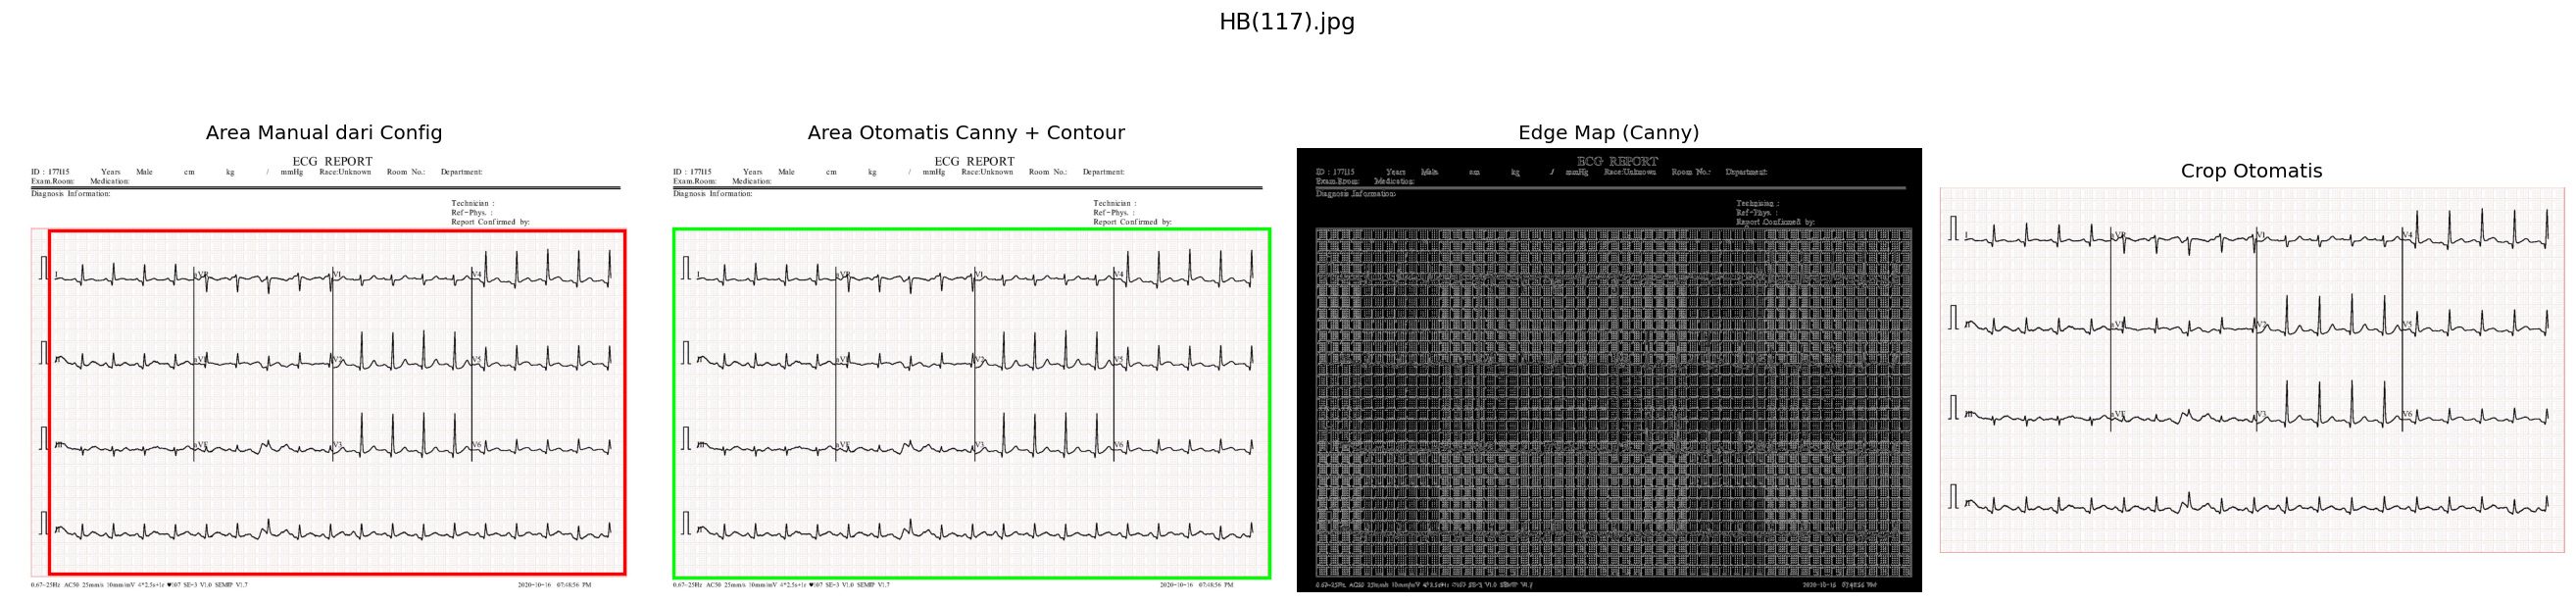

{'manual_rect': (130, 290, 2170, 1505), 'auto_rect': (68, 283, 2177, 1518)}

In [4]:
preview_area_detection(sample_path)


## Preview 2: Tahapan Pembersihan ala `ecg-miner`

Tahapan yang divisualisasikan:

1. crop area ECG
2. konversi ke HSV lalu lihat channel `V` / brightness
3. buat brightness mask
4. deteksi grid merah/pink dengan `red_mask`
5. putihkan area grid merah lalu threshold sinyal gelap
6. bentuk `grid_mask` horizontal dan vertikal untuk membuang sisa kotak grid
7. rapikan hasil akhir dengan `outline_borders`


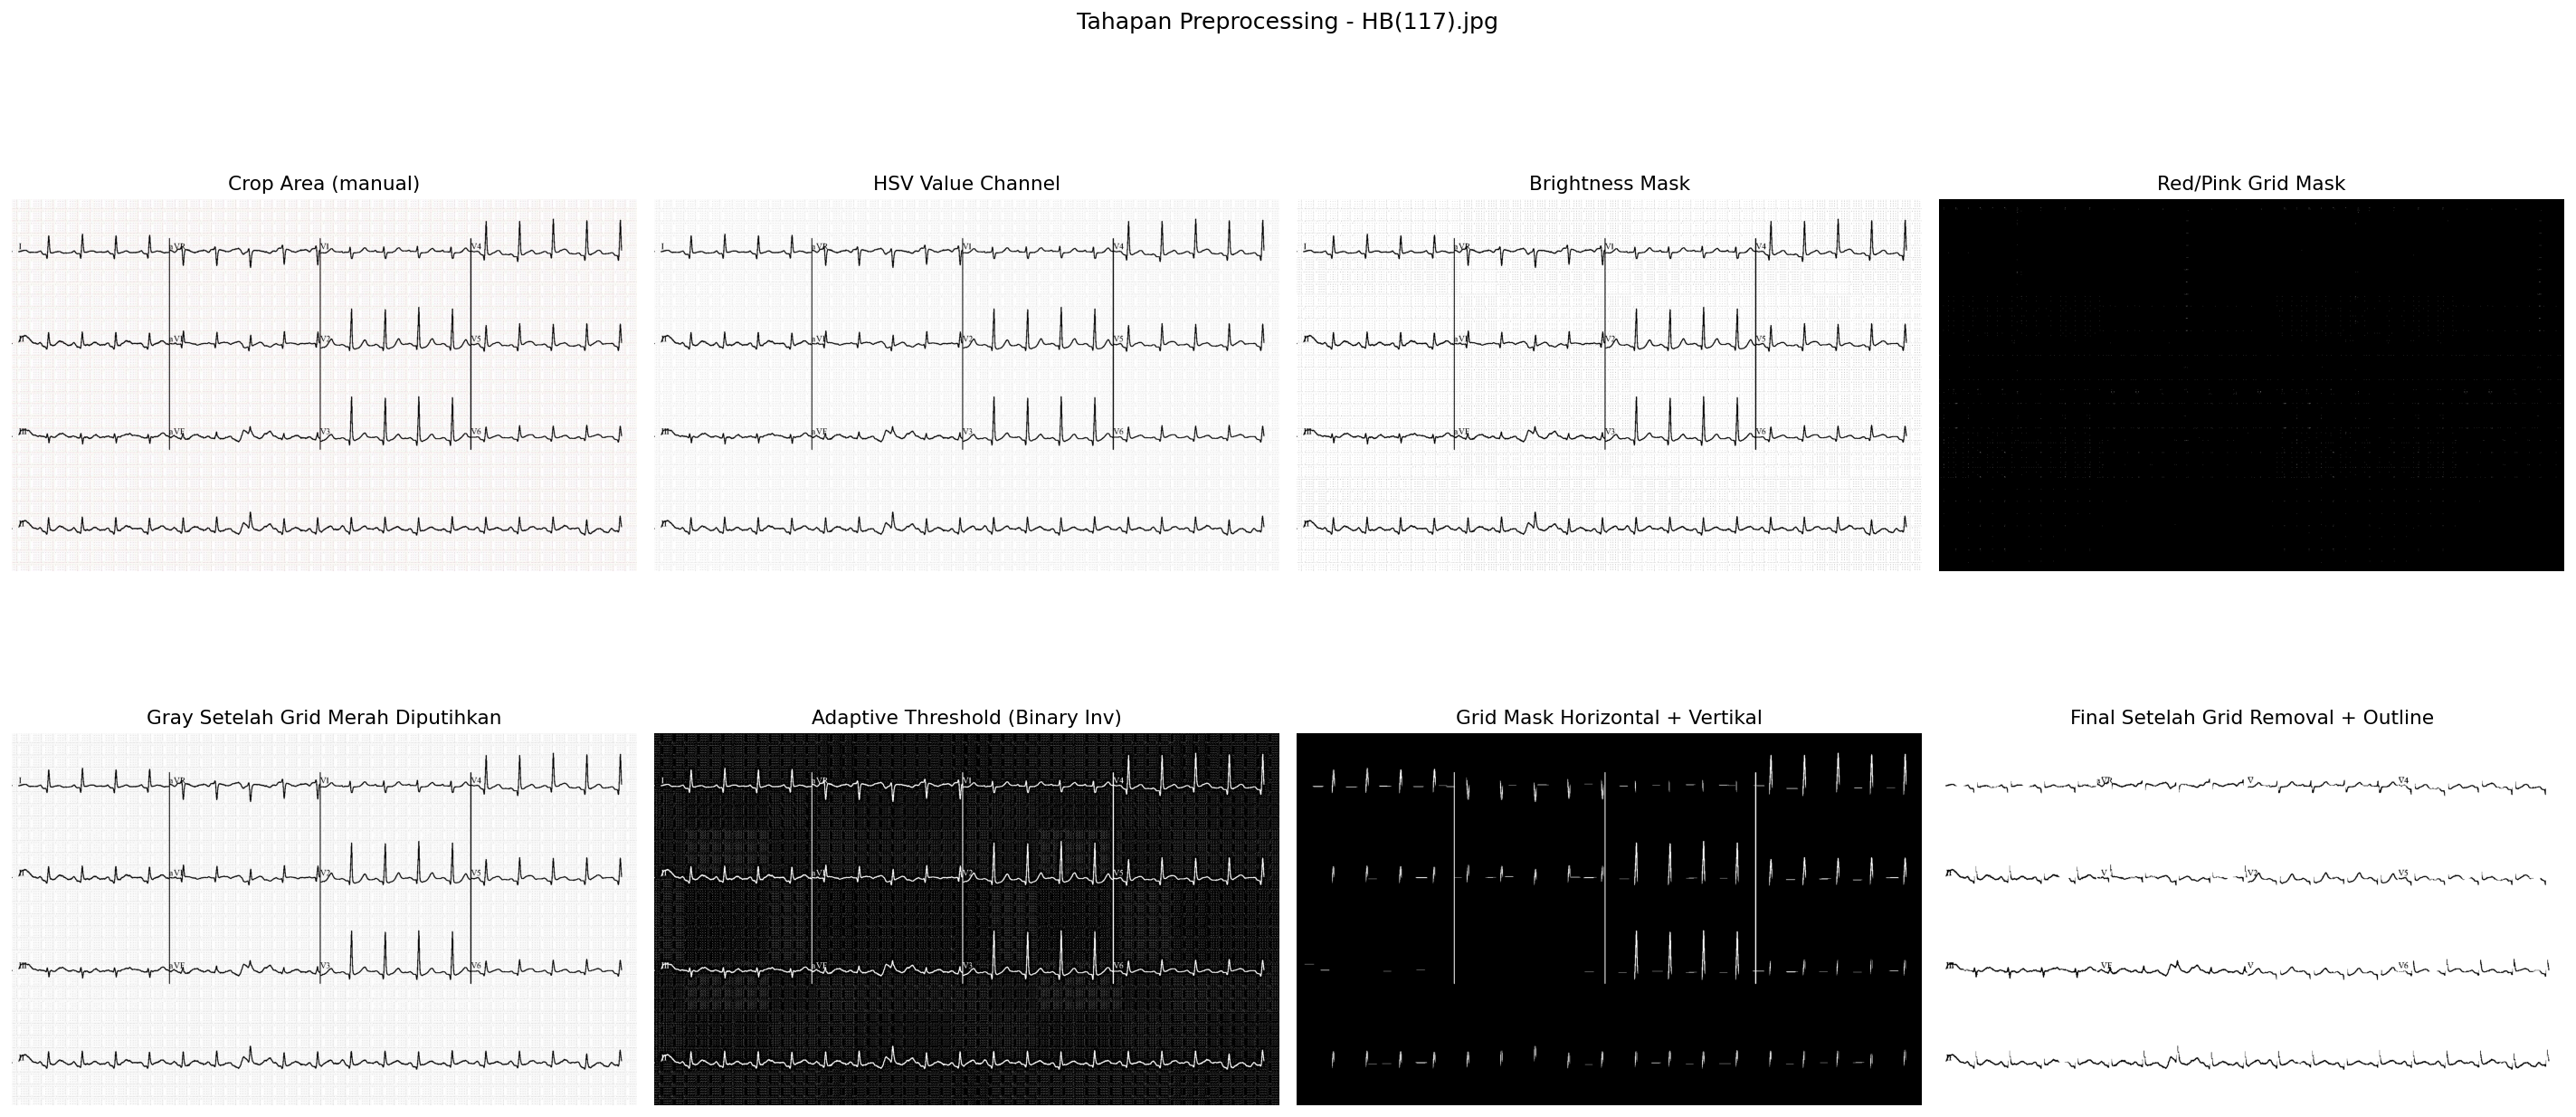

In [5]:
_ = preview_preprocess_stages(sample_path, crop_mode="manual")


## Preview 3: Bandingkan Hasil Akhir pada Beberapa Kelas

Sel ini menampilkan contoh dari beberapa folder kelas agar kamu bisa cepat melihat apakah cleaning ala `ecg-miner` cocok untuk dataset kamu.


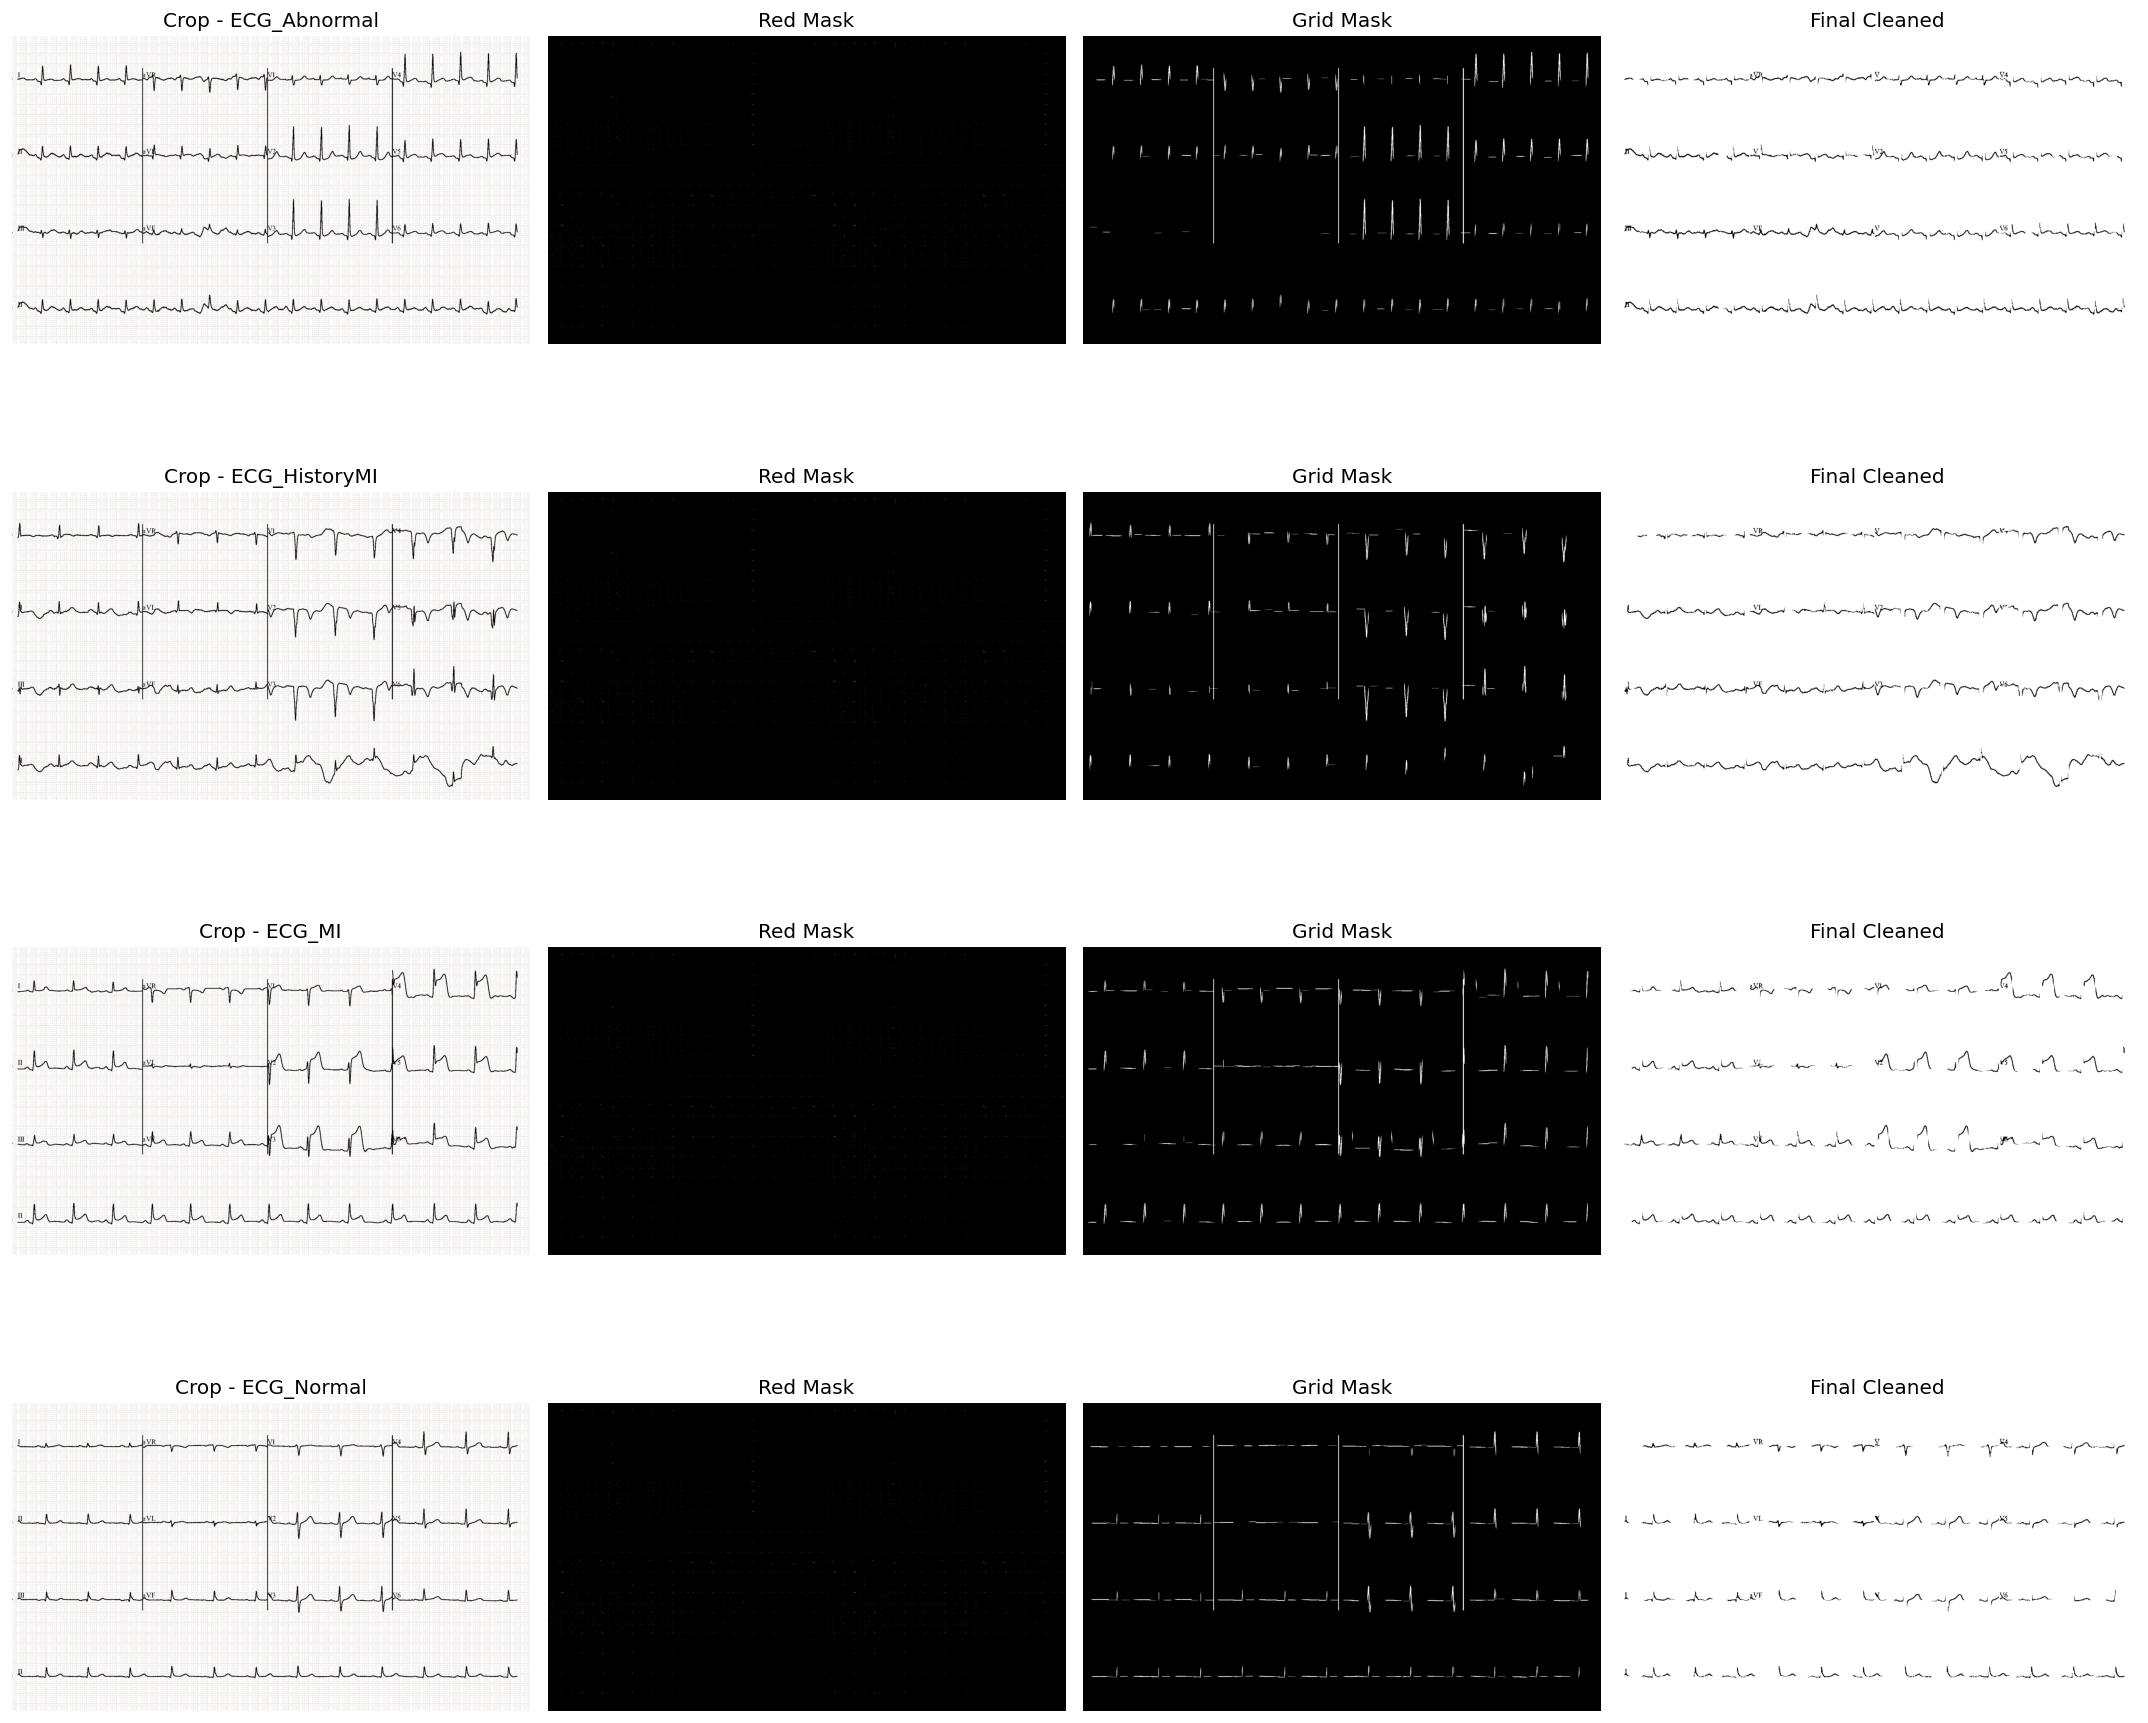

In [6]:
preview_multiple_samples(crop_mode="manual", random_state=Config.seed)


## Simpan Hasil Preprocessing untuk Seluruh Dataset

Secara default sel ini memakai crop manual dari `Config.ecg_area_coordinates`, lalu cleaning ala `ecg-miner`, dan menyimpan hasil final ke:

`data/preprocessed/ecgminer_style_clean/`

Jika kamu ingin menguji crop otomatis ala Canny, ganti `crop_mode` menjadi `"auto"`.


In [7]:
# Jalankan jika preview sudah sesuai.
# preprocess_dataset_ecgminer_style(
#     input_root=RAW_DATA_ROOT,
#     output_root=OUTPUT_ROOT,
#     crop_mode="manual",
# )
